# Notebook 4: Spatial Classification
This notebook will contain code for classification through spatial analysis, harnessing CNN architectures such as ResNet for this task.

We're starting off with a model using just one band -> with index 102 corresponding to wavelength 668.8nm.

Here, we want to try and answer:
> Can spatial information compensate for reduced spectral information?

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes, closing, opening, disk

from hsi_utils import load_data, load_cube, build_foreground_mask

In [2]:
SEED = 51

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # use gpu if available, otherwise cpu
device

device(type='cpu')

In [3]:
train_files, valid_files, test_files, files_split = load_data()

varieties = ["barley", "corn", "flax"]
class_to_idx = {v: i for i, v in enumerate(varieties)}
idx_to_class = {i: v for v, i in class_to_idx.items()}

print("Train images:", len(train_files))
print("Valid images:", len(valid_files))
print("Test images:", len(test_files))

display(files_split[["sample_name", "variety", "size", "rep", "split"]].head())

 Mounting E: into /mnt/e ...
[OK] Found dataset: /mnt/e/HSI_Dataset_2/Elements/data
 Removing old link /home/isaacmuscat/Grain-Variety-Classification/data_external
[OK] Linked /home/isaacmuscat/Grain-Variety-Classification/data_external -> /mnt/e/HSI_Dataset_2/Elements/data
Sample files:
   raw/calibration/FX10/calibration_1705a_0.hdf5
   raw/calibration/FX10/calibration_1705a_1.hdf5
   raw/calibration/FX10/calibration_1705a_2.hdf5
   raw/calibration/FX10/calibration_1705a_3.hdf5
   raw/calibration/FX10/calibration_1705_0.hdf5
   raw/calibration/FX10/calibration_1705_1.hdf5
   raw/calibration/FX10/calibration_1705_2.hdf5
   raw/calibration/FX10/calibration_1705_3.hdf5
   raw/calibration/Snapshot/processed/calibration_1705a_0/image_0000000003.hdr
   raw/calibration/Snapshot/processed/calibration_1705a_1/image_0000000000.hdr
ROOT:     /mnt/e/HSI_Dataset_2/Elements/data
Basepath: /mnt/e/HSI_Dataset_2/Elements/data/raw/FX10
OUTDIR:   /mnt/e/HSI_Dataset_2/Elements/data/processed/quickrun
To

/home/isaacmuscat/Grain-Variety-Classification/hsi_utils.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_split)


,sample_name,variety,size,rep,split
0,barley_l0,barley,l,0,train
1,barley_l1,barley,l,1,train
2,barley_l2,barley,l,2,train
3,barley_l3,barley,l,3,valid
4,barley_l4,barley,l,4,test


In [4]:
# From spectral_exploration.ipynb
# Top band index - 102
# Top wavelength - 668.8 nm

TARGET_WAVELENGTH = 668.8
PCA_BAND_INDEX = 102

print("Using PCA-selected band index:", PCA_BAND_INDEX)
print("Target wavelength:", TARGET_WAVELENGTH, "nm")

Using PCA-selected band index: 102
Target wavelength: 668.8 nm


In [ ]:
# we reduce the effect of extreme reflectance values and makes images more comparable across samples
def percentile_normalize(img, p_low=2, p_high=98):
    """
    Normalise one image to [0, 1] using robust percentiles.
    """
    lo, hi = np.percentile(img, [p_low, p_high])
    img = (img - lo) / (hi - lo + 1e-6)
    img = np.clip(img, 0, 1)
    return img.astype(np.float32)


def load_single_band_image(filepath, target_wavelength=668.8, crop=True, apply_mask=True):
    hcube, wlens, darkref, whiteref = load_cube(filepath)

    if crop:
        hcube = hcube[50:1050, 50:925, :]

    band_idx = int(np.argmin(np.abs(wlens - target_wavelength)))
    band_img = hcube[:, :, band_idx].astype(np.float32)

    if apply_mask:
        mask = build_foreground_mask(
            hcube,
            min_size=500,
            otsu_factor=0.50,
            use_watershed=True
        )

    band_img = band_img * mask

    band_img = percentile_normalize(band_img)

    return band_img, band_idx, wlens[band_idx]

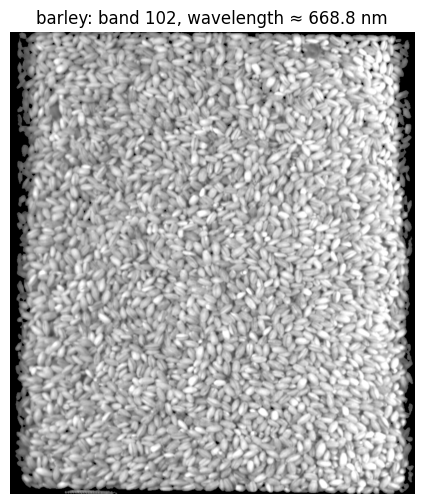

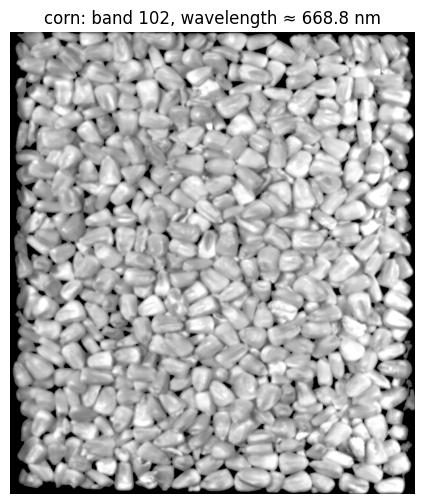

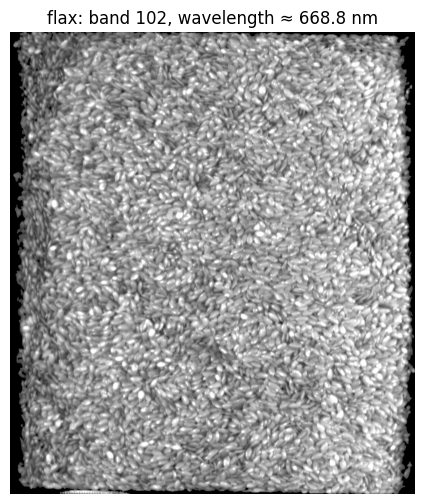

In [6]:
for var in varieties:
    subset = train_files[train_files["variety"] == var]

    if subset.empty:
        continue

    row = subset.iloc[0]
    img, band_idx, actual_wl = load_single_band_image(
        row["filepath_FX10"],
        target_wavelength=TARGET_WAVELENGTH
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"{var}: band {band_idx}, wavelength ≈ {actual_wl:.1f} nm")
    plt.axis("off")
    plt.show()

In [7]:
# --- Dataset for no. of samples, how to load a sample and which label belongs to which sample ---

class SingleBandHSIDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_idx,
        target_wavelength=668.8,
        transform=None,
        crop=True,
        apply_mask=True
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.class_to_idx = class_to_idx
        self.target_wavelength = target_wavelength
        self.transform = transform
        self.crop = crop
        self.apply_mask = apply_mask

    def __len__(self):
        return len(self.df) # returns number of images

    def __getitem__(self, idx): # loads an image and a label
        row = self.df.iloc[idx] # gets a file

        img, band_idx, actual_wl = load_single_band_image(
            row["filepath_FX10"],
            target_wavelength=self.target_wavelength,
            crop=self.crop,
            apply_mask=self.apply_mask
        ) # load single band image

        # Convert [H, W] float image to PIL image
        img_uint8 = (img * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_uint8, mode="L") # convert to grayscale PIL image

        if self.transform is not None:
            img_tensor = self.transform(img_pil) # resizing, normalization etc.
        else:
            img_tensor = T.ToTensor()(img_pil)

        label = self.class_to_idx[row["variety"]] # returns numeric class label

        return img_tensor, label

Here, a custom PyTorch Dataset was created because the data is not in the form of ordinary PNG files.

Each sample must be:
* Loaded from an HSI cube
* Reduced to the selected wavelength
* Masked
* Normalized 
* Transformed
* and paired with a label. 

This is the standard way to handle custom datasets in PyTorch.

In [9]:
IMG_SIZE = 224 # typical size for resnet architectures
BATCH_SIZE = 8

train_transform = T.Compose([ 
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
]) # the actions taken here are augmentations -> artificially varying the training images so that we reduce overfitting; only for train set

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = SingleBandHSIDataset(
    train_files,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=train_transform
)

valid_dataset = SingleBandHSIDataset(
    valid_files,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=eval_transform
)

test_dataset = SingleBandHSIDataset(
    test_files,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=eval_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # feeds data into model in mini-batches
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 4
Valid batches: 2
Test batches: 2


In [10]:
def build_resnet18_1channel(num_classes=3):
    model = resnet18(weights=None) # creates resnet without pretraining

    # change first convolution from RGB input to 1-channel input
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # replace final classification layer - we want to predict just 3 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


model = build_resnet18_1channel(num_classes=len(varieties)).to(device)
model

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
criterion = nn.CrossEntropyLoss() # loss for multi-class classification

# adam optimizer typical for updating model weights -> adapts learning rate per parameter + better weight decay handling
optimizer = torch.optim.AdamW( 
    model.parameters(),
    lr=1e-4, # small learning rate -> small dataset so we're a bit more conservative with this choice
    weight_decay=1e-4 
) 

# scheduler lowers learning rate if valid. loss stops improving; helps training settle instead of continuing with an inflated LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [12]:
# --- handling training + validation ---
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval() # gradients not computed -> validation

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

In [16]:
EPOCHS = 5
PATIENCE = 2

best_valid_loss = np.inf
best_model_state = None
epochs_without_improvement = 0

history = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer=optimizer)
    valid_loss, valid_acc = run_one_epoch(model, valid_loader, optimizer=None)

    scheduler.step(valid_loss) # update LR if needed

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f}, train acc={train_acc:.3f} | "
        f"valid loss={valid_loss:.4f}, valid acc={valid_acc:.3f}"
    )

    if valid_loss < best_valid_loss: # keep best valid. loss state
        best_valid_loss = valid_loss
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_state)

Epoch 01 | train loss=1.0409, train acc=0.444 | valid loss=1.0154, valid acc=0.444
Epoch 02 | train loss=0.6751, train acc=0.630 | valid loss=1.0451, valid acc=0.556
Epoch 03 | train loss=0.7588, train acc=0.741 | valid loss=1.4883, valid acc=0.444
Early stopping triggered.


<All keys matched successfully>

,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.040918,0.444444,1.015418,0.444444
1,2,0.675116,0.629630,1.045122,0.555556
2,3,0.758805,0.740741,1.488288,0.444444


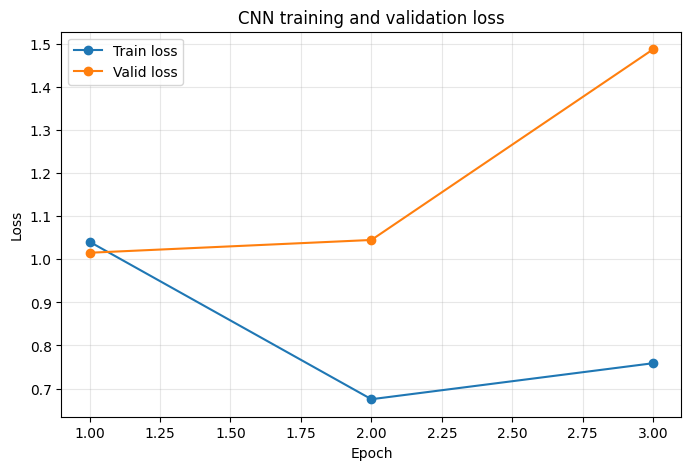

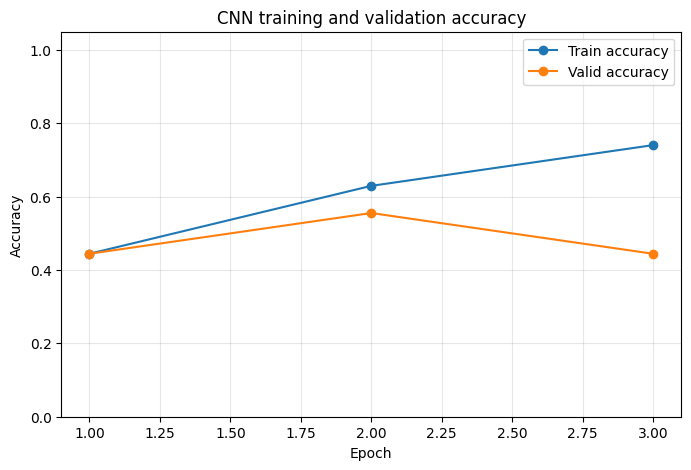

In [17]:
history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], marker="o", label="Valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], marker="o", label="Valid accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN training and validation accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training is improving but validation is getting worse -> overfitting!!

In [18]:
def predict(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = predict(model, test_loader)

test_acc = accuracy_score(y_true, y_pred)

print("Test accuracy:", round(test_acc, 4))
print()
print(classification_report(
    y_true,
    y_pred,
    target_names=varieties
))

Test accuracy: 0.4444

              precision    recall  f1-score   support

      barley       0.00      0.00      0.00         3
        corn       1.00      0.33      0.50         3
        flax       0.38      1.00      0.55         3

    accuracy                           0.44         9
   macro avg       0.46      0.44      0.35         9
weighted avg       0.46      0.44      0.35         9



/home/isaacmuscat/Grain-Variety-Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isaacmuscat/Grain-Variety-Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isaacmuscat/Grain-Variety-Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

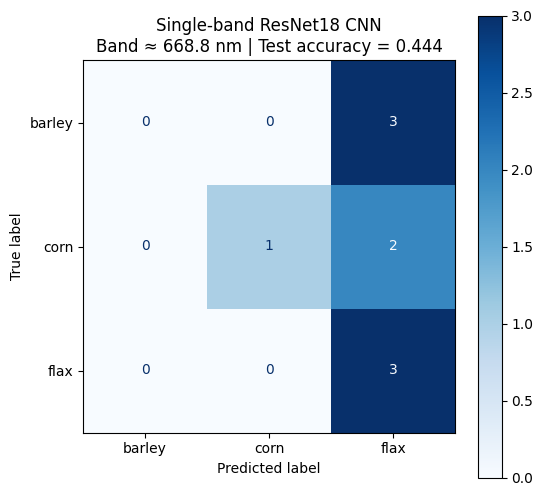

In [19]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=varieties
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(
    f"Single-band ResNet18 CNN\n"
    f"Band ≈ {TARGET_WAVELENGTH} nm | Test accuracy = {test_acc:.3f}"
)
plt.show()

In [20]:
SAVE_PATH = "spatial_resnet18_single_band_668nm.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "target_wavelength": TARGET_WAVELENGTH,
    "pca_band_index": PCA_BAND_INDEX,
    "history": history
}, SAVE_PATH)

print("Saved model to:", SAVE_PATH)

Saved model to: spatial_resnet18_single_band_668nm.pt
